<a href="https://colab.research.google.com/github/Sonny-Star000/MSc-Data-Science-Dissertation/blob/main/Customer_churn_banking_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing google drive

In [ ]:
from google.colab import drive # Import drive to access datsets and files
import os # Loads the os file to handle file paths , dictionaries , and environment variables
import random # Loads python's random module to handle random number generation and data changing
import numpy as np # Numpy is a open source library for arrays and numerical operations
import tensorflow as tf # Tensor Flow is an open source frame for machine learning and AI tasks
import torch  # Import torch for deep learning and machine learning

# Mount Drive and set seeds for reproducibility
drive.mount('/content/drive')
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Mounted at /content/drive


Load dataset from google drive

In [ ]:
import pandas as pd # Pandas is a dataframe library for data analysis and data manipulation
from sklearn.model_selection import train_test_split # Import train_test_split from scikit learn
from sklearn.metrics import confusion_matrix # Import the confusion matrix tool from scikit learn

#  Load the data using the full path
file_path = '/content/drive/MyDrive/Dissertation bank churn data/Churn_Modelling.csv'
df = pd.read_csv(file_path)



# Checking data is loaded from file_path , datashape from df.shape and any null values from df.isnull
print(f"Data loaded from: {file_path}")
print(f"Dataset shape: {df.shape}")
print(f"Are there any null values left? {df.isnull().sum().sum() > 0}")

Data loaded from: /content/drive/MyDrive/Dissertation bank churn data/Churn_Modelling.csv
Dataset shape: (10000, 14)
Are there any null values left? False


In [ ]:
import pandas as pd # Import pandas for data analysis and data manipulation


file_path = '/content/drive/MyDrive/Dissertation bank churn data/Churn_Modelling.csv'

df = pd.read_csv(file_path)

print(df.head())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

Data cleaning

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


array([[<Axes: title={'center': 'Balance'}>,
        <Axes: title={'center': 'EstimatedSalary'}>],
       [<Axes: title={'center': 'CreditScore'}>, <Axes: >]], dtype=object)

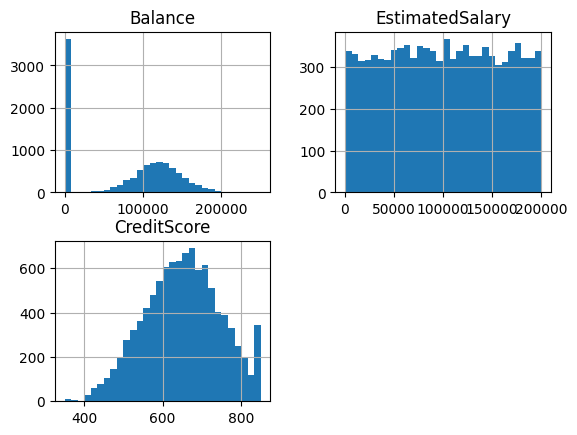

In [ ]:
import pandas as pd
import seaborn as sns

# Check for missing values
print(df.isnull().sum())

# Check the balance of the 'Exited' column
print(df['Exited'].value_counts(normalize=True))

# Distribution of numerical features
df[['Balance', 'EstimatedSalary', 'CreditScore']].hist(bins=30)

In [ ]:

# Data cleaning for missing values
if df.isnull().sum().sum() > 0:
    print("Cleaning missing values...")

    df = df.fillna(df.median())
    print("Data is now clean.")
else:
    print("Data is already clean.")

Data is already clean.


In [ ]:
#  Prepare the data
# Dropping non-numeric columns that aren't requied for prediction
df_clean = df.drop(columns=['CustomerId', 'RowNumber', 'Surname'], errors='ignore')
df_clean = pd.get_dummies(df_clean, drop_first=True)

#  Define features and target
X = df_clean.drop(columns=['Exited'])
y = df_clean['Exited']

#  Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

In [ ]:
# Checking the Type of y_train and First 5 values of y_train
print("Type of y_train:", type(y_train))
print("First 5 values of y_train:")
print(y_train.head())

Type of y_train: <class 'pandas.core.series.Series'>
First 5 values of y_train:
9254    0
1561    0
1670    1
6087    1
6669    1
Name: Exited, dtype: int64


Explotory Data Analysis

In [ ]:
#  Prepare the data
# Dropping non-numeric columns that aren't needed for prediction
df_clean = df.drop(columns=['CustomerId', 'RowNumber', 'Surname'], errors='ignore')
df_clean = pd.get_dummies(df_clean, drop_first=True)

#  Define features and target
X = df_clean.drop(columns=['Exited'])
y = df_clean['Exited']

#  Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt # Import matplotlib for plotting results

# Set the theme style
sns.set_theme(style="whitegrid")

In [ ]:
# Check for data types and missing values
print(df.info())

# Check for any missing values
print(df.isnull().sum())

# Get summary statistics for numerical columns
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geogr

/tmp/ipykernel_875/4018250565.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=df, palette='viridis')


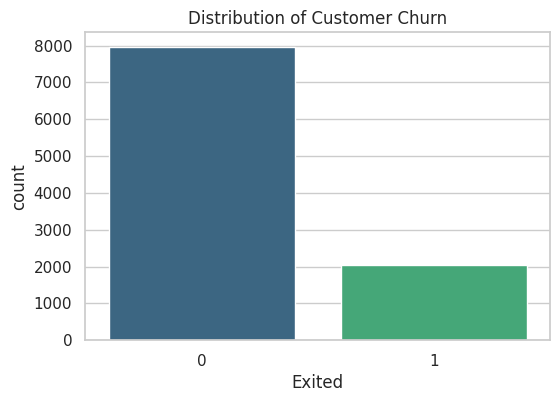

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Exited', data=df, palette='viridis')
plt.title('Distribution of Customer Churn')
plt.show()

In [ ]:
# Get the exact counts
print(df['Exited'].value_counts())

Exited
0    7963
1    2037
Name: count, dtype: int64


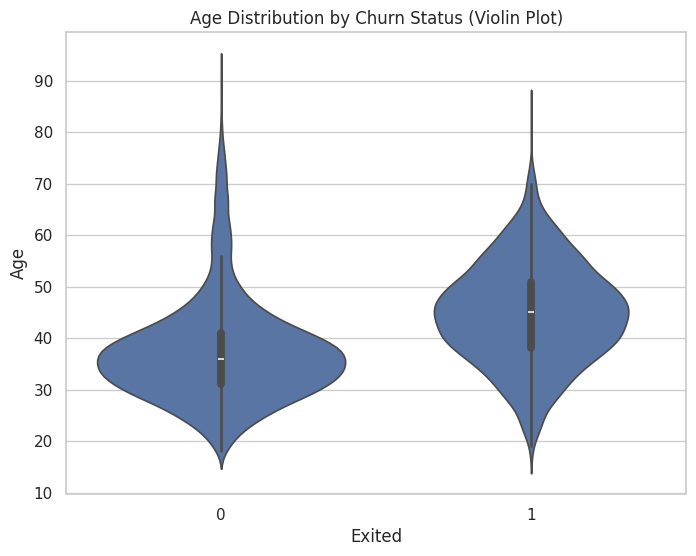

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.violinplot(x='Exited', y='Age', data=df)
plt.title('Age Distribution by Churn Status (Violin Plot)')
plt.show()

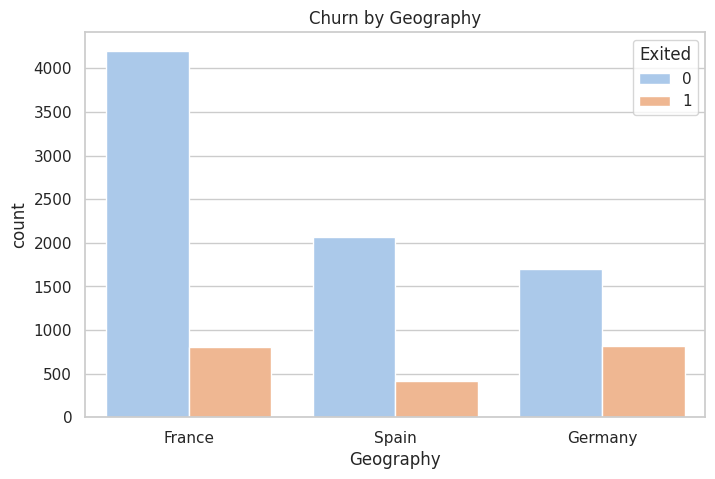

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Geography', hue='Exited', data=df, palette='pastel')
plt.title('Churn by Geography')
plt.show()

In [ ]:
# Percentages for geography
churn_rate_by_geo = df.groupby('Geography')['Exited'].mean() * 100
print(churn_rate_by_geo)

Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64


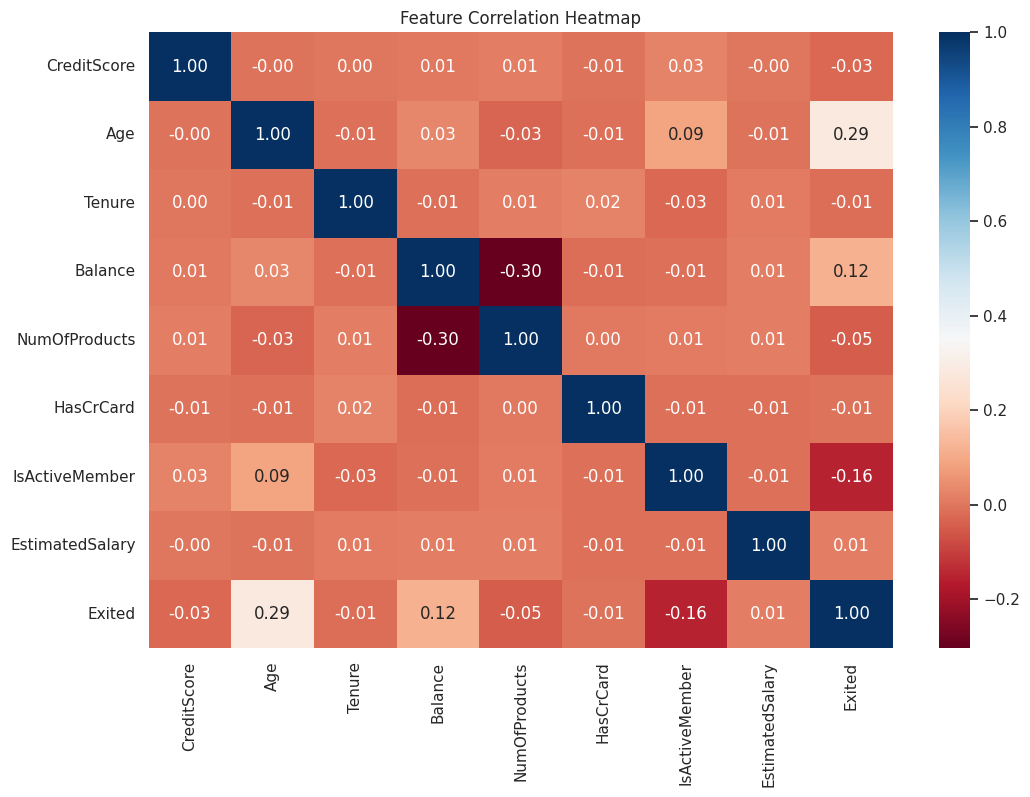

In [ ]:
# Drop non-informative identifiers before calculating correlation
df_corr = df.drop(columns=['RowNumber', 'CustomerId'], errors='ignore')

# Calculate correlation matrix
corr_matrix = df_corr.select_dtypes(include=['number']).corr()

# Plot the feature correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

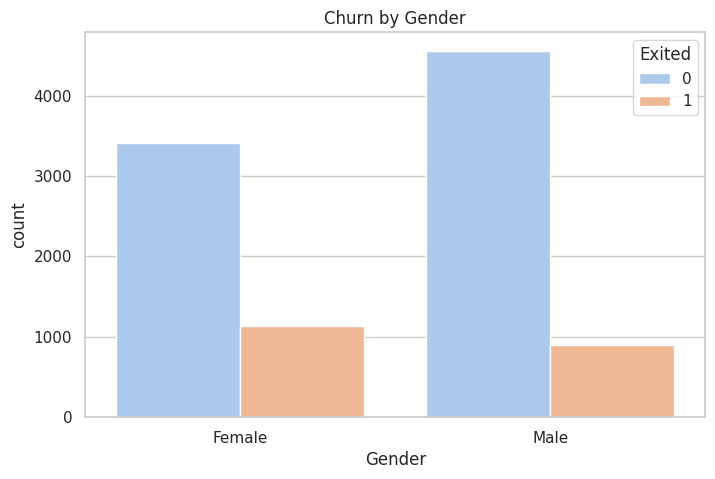

In [ ]:
plt.figure(figsize=(8, 5)) # Plot the distribution of customer across genders
sns.countplot(x='Gender', hue='Exited', data=df, palette='pastel')
plt.title('Churn by Gender')
plt.show()

Churn by Number of Products

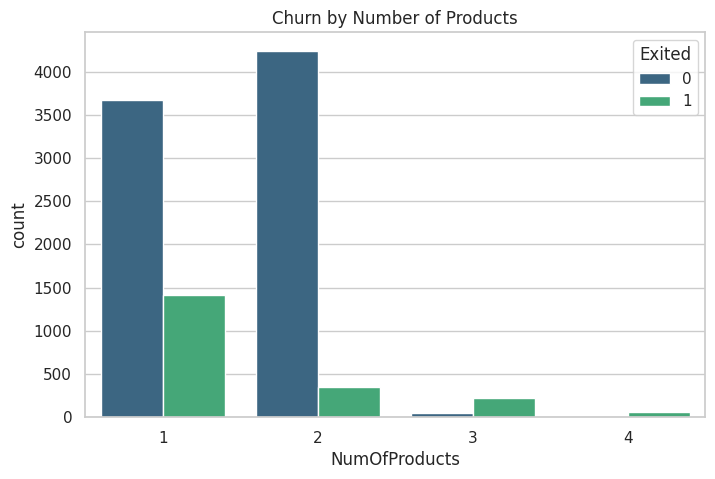

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='NumOfProducts', hue='Exited', data=df, palette='viridis')
plt.title('Churn by Number of Products')
plt.show()

 Churn by Has Credit Card

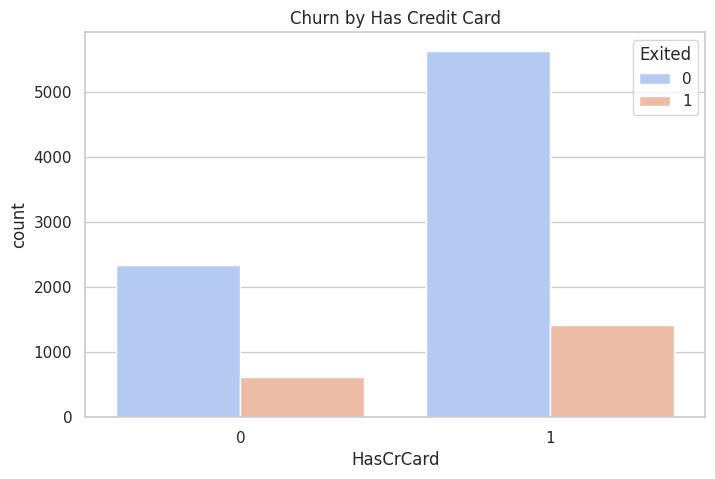

In [ ]:
plt.figure(figsize=(8, 5)) # Plot the distribution of churned customers by credit card ownership
sns.countplot(x='HasCrCard', hue='Exited', data=df, palette='coolwarm')
plt.title('Churn by Has Credit Card')
plt.show()

 Churn by Is Active Member

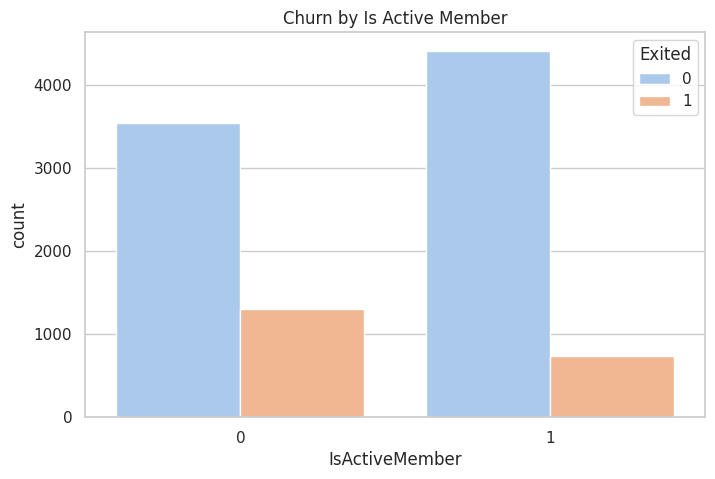

In [ ]:
plt.figure(figsize=(8, 5)) # Plot the distribution of churned customers by active member
sns.countplot(x='IsActiveMember', hue='Exited', data=df, palette='pastel')
plt.title('Churn by Is Active Member')
plt.show()

Credit score by Churn Status

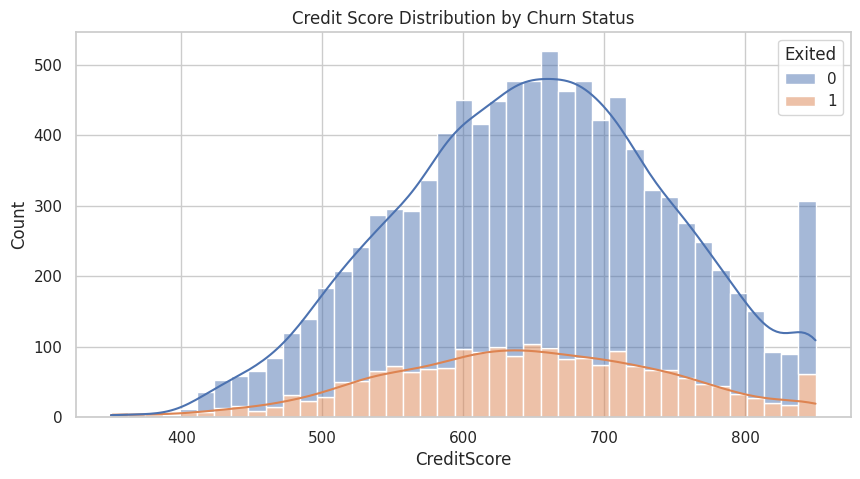

In [ ]:
plt.figure(figsize=(10, 5)) # Plot the distribution of churned customers by credit score
# This shows the credit card distribution
sns.histplot(data=df, x='CreditScore', hue='Exited', kde=True, multiple='stack')
plt.title('Credit Score Distribution by Churn Status')
plt.show()

Balance by churn status

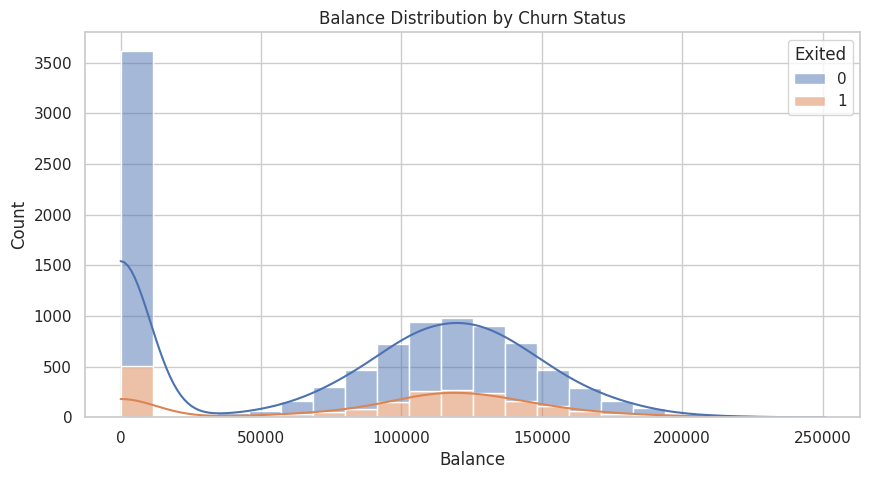

In [ ]:
plt.figure(figsize=(10, 5)) # Plot the distribution of churned customers by balance distribution
# This shows the balance distribution
sns.histplot(data=df, x='Balance', hue='Exited', kde=True, multiple='stack')
plt.title('Balance Distribution by Churn Status')
plt.show()

Estimated salary by churn status

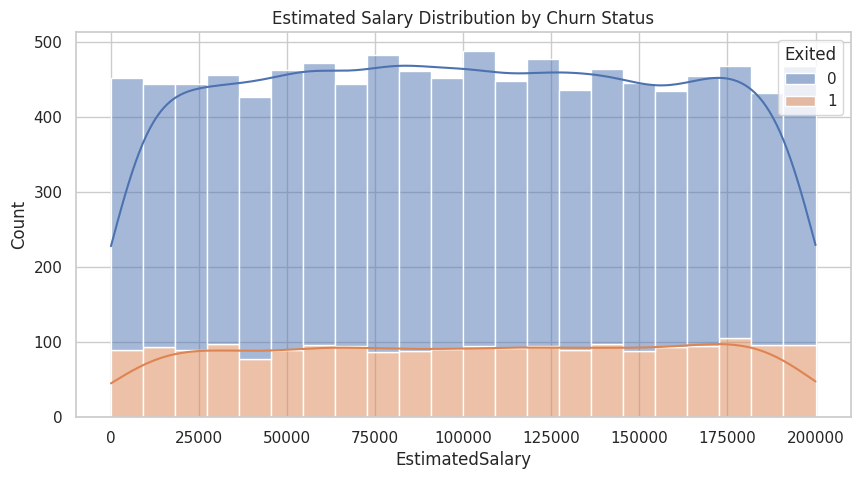

In [ ]:
plt.figure(figsize=(10, 5)) # Plot the distribution of churned customers by estimated salary
# This shows the estimated salary
sns.histplot(data=df, x='EstimatedSalary', hue='Exited', kde=True, multiple='stack')
plt.title('Estimated Salary Distribution by Churn Status')
plt.show()

Exploratory data survival analysis

In [ ]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 9.0 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4120 sha256=fac5b21dc9d4710a47cacb857e5aae6f3311f59e415632c80e975572d2b7a266
  Stored in directory: /root/.cache/pip/wheels/7e/16/46/9477f188924292d3bf1fb8fb42844201591abfc19b7ba6d868
Successfully built autograd-gamma


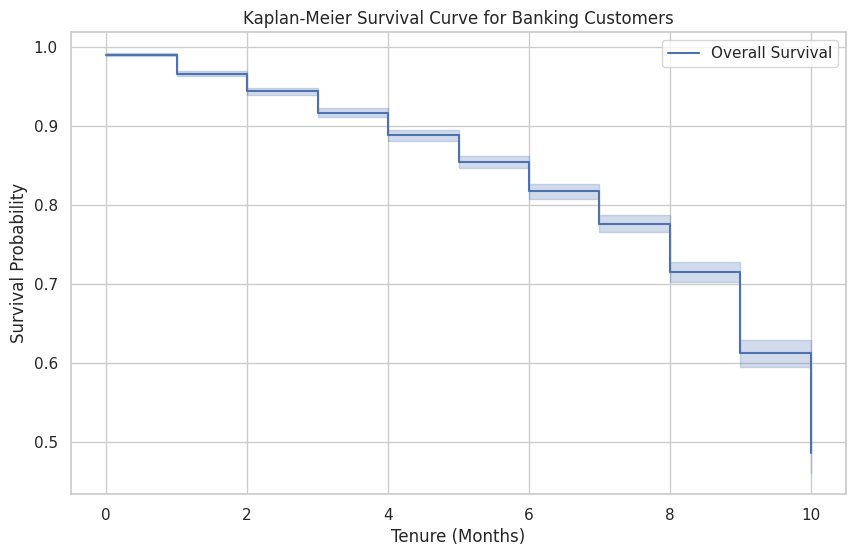

Kaplan-Meier plot generated successfully using 'exited' as the churn indicator.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter # Import the Kaplan-Meier for survival analysis

# Standardize column names
df.columns = df.columns.str.strip().str.lower()


kmf = KaplanMeierFitter()
kmf.fit(durations=df['tenure'], event_observed=df['exited'], label='Overall Survival')

# Plot the Survival Curve for banking customers
plt.figure(figsize=(10, 6))
kmf.plot_survival_function()
plt.title('Kaplan-Meier Survival Curve for Banking Customers')
plt.xlabel('Tenure (Months)')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()

print("Kaplan-Meier plot generated successfully using 'exited' as the churn indicator.")

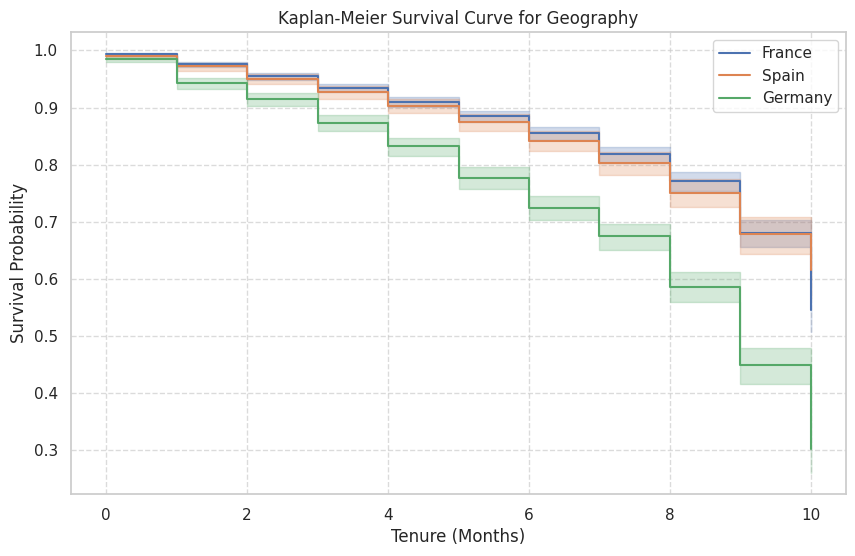

Plot generated successfully.


In [ ]:

df.columns = [col.strip().lower() for col in df.columns]


target_col = 'geography'
if target_col not in df.columns:
    print(f"CRITICAL ERROR: {target_col} is not in {df.columns.tolist()}")
else:

    kmf = KaplanMeierFitter()
    plt.figure(figsize=(10, 6))

    for category in df[target_col].unique():
        mask = (df[target_col] == category)
        kmf.fit(df.loc[mask, 'tenure'], event_observed=df.loc[mask, 'exited'], label=str(category))
        kmf.plot_survival_function()

     # Plot the Survival Curve by geography
    plt.xlabel('Tenure (Months)')
    plt.ylabel('Survival Probability')
    plt.title(f'Survival Analysis by {target_col.capitalize()}')
    plt.title('Kaplan-Meier Survival Curve for Geography')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    print("Plot generated successfully.")

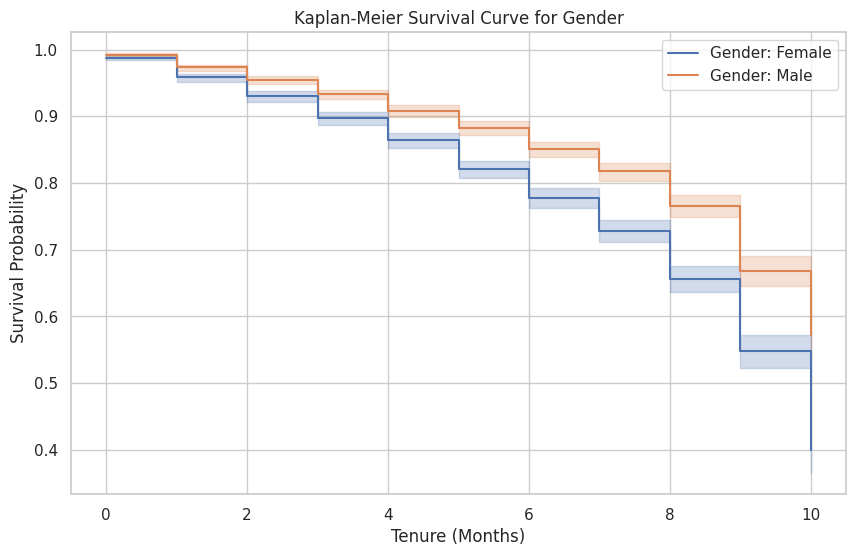

P-Value for Gender Differences: 0.0000


In [ ]:
#  Initialize the Fitter
kmf_gender = KaplanMeierFitter()

#  Plotting curves by gender
plt.figure(figsize=(10, 6))
for gender_type in df['gender'].unique():
    mask = (df['gender'] == gender_type)
    kmf_gender.fit(durations=df.loc[mask, 'tenure'],
                   event_observed=df.loc[mask, 'exited'],
                   label=f'Gender: {gender_type}')
    kmf_gender.plot_survival_function()

plt.title('Survival Analysis by Gender')
plt.title('Kaplan-Meier Survival Curve for Gender')
plt.xlabel('Tenure (Months)')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()

#  Statistical Validation (Log-Rank Test)
from lifelines.statistics import logrank_test
group_male = df[df['gender'] == 'Male']
group_female = df[df['gender'] == 'Female']

results = logrank_test(group_male['tenure'], group_female['tenure'],
                       group_male['exited'], group_female['exited'])

print(f"P-Value for Gender Differences: {results.p_value:.4f}")

Cox-Ph

<lifelines.CoxPHFitter: fitted with 10000 total observations, 7963 right-censored observations>
             duration col = 'tenure'
                event col = 'exited'
      baseline estimation = breslow
   number of observations = 10000
number of events observed = 2037
   partial log-likelihood = -16480.21
         time fit was run = 2026-09-12 16:59:20 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
rownumber         -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
creditscore       -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
gender            -0.39      0.68      0.04           -0.47           -0.30                0.62                0.74
age                0.05      1.05      0.00            0.04            0.05                1.05                1.05
balance            0.00      1.00      0.00            0.00            0.00                1.00                1.00
numofproducts     -0.07      0.94      0.04           -0.14            0.01                0.87                1.01
hascrcard         -0.06      0.94      0.05           -0.16            0.03                0.85                1.03
isactivemember    -0.74      0.48      0.05           -0.83           -0.65                0.44                0.52
estimatedsalary   -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
geography_Germany  0.49      1.63      0.05            0.38            0.60                1.47                1.82
geography_Spain    0.05      1.05      0.06           -0.07            0.17                0.93                1.18

                   cmp to      z      p  -log2(p)
covariate                                        
rownumber            0.00  -1.69   0.09      3.46
creditscore          0.00  -2.21   0.03      5.19
gender               0.00  -8.62 <0.005     57.10
age                  0.00  26.77 <0.005    521.86
balance              0.00   4.80 <0.005     19.27
numofproducts        0.00  -1.72   0.08      3.56
hascrcard            0.00  -1.32   0.19      2.42
isactivemember       0.00 -15.56 <0.005    178.97
estimatedsalary      0.00  -0.02   0.98      0.03
geography_Germany    0.00   9.00 <0.005     62.00
geography_Spain      0.00   0.80   0.42      1.24
---
Concordance = 0.72
Partial AIC = 32982.42
log-likelihood ratio test = 1159.81 on 11 df
-log2(p) of ll-ratio test = 801.02

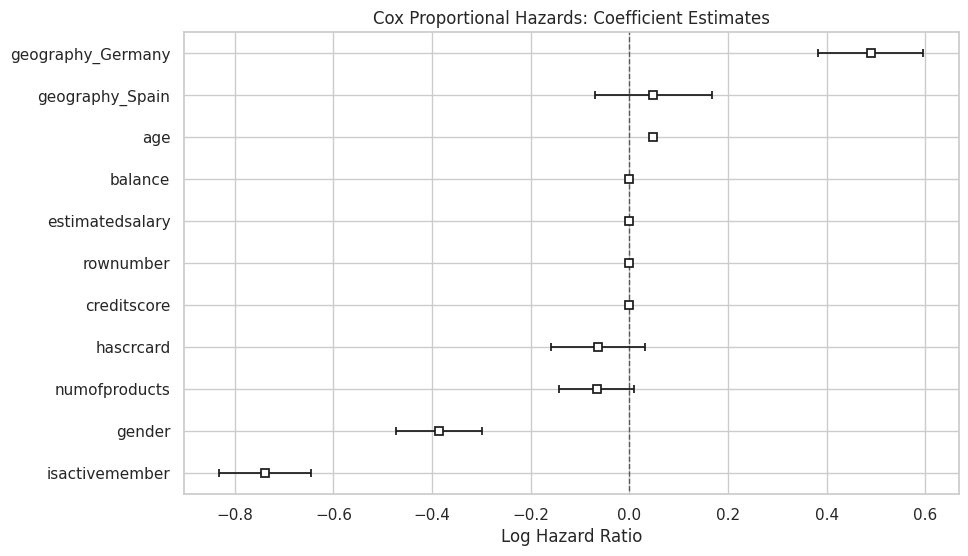

In [ ]:
import matplotlib.pyplot as plt

#  Drop the columns that aren't useful (like Surname and CustomerId)
df_model = df.drop(columns=['surname', 'customerid'], errors='ignore')

#  Encode categorical variables into numbers
df_model['gender'] = df_model['gender'].map({'Female': 0, 'Male': 1})
df_model = pd.get_dummies(df_model, columns=['geography'], drop_first=True)

#  Initialize and fit the model
from lifelines import CoxPHFitter
cph = CoxPHFitter()
cph.fit(df_model, duration_col='tenure', event_col='exited')
cph.print_summary()

#  Plot the results for coefficients
plt.figure(figsize=(10, 6))
cph.plot()
plt.title("Cox Proportional Hazards: Coefficient Estimates")
plt.xlabel("Log Hazard Ratio")
plt.grid(True)
plt.show()

Install pycox

In [ ]:
!pip install pycox

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 492.7/492.7 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 18.3 MB/s eta 0:00:00
  Created wheel for feather-format: filename=feather_format-0.4.1-py3-none-any.whl size=2490 sha256=2731adf7cfd4a4aa80df1453708fdd59d0244f573b93e872d2544bb6651dbe29
  Stored in directory: /root/.cache/pip/wheels/8b/a4/18/c08950203337466da891a5e52caa5b8f1920114f54fe846883
Successfully built feather-format


X Train

In [ ]:
from sklearn.model_selection import train_test_split # Import train_test_split to split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (8000, 11)
y_train shape: (8000,)


In [ ]:
print("Type of y_train:", type(y_train))
print("First 5 values of y_train:", y_train.head())

Type of y_train: <class 'pandas.core.series.Series'>
First 5 values of y_train: 9254    0
1561    0
1670    1
6087    1
6669    1
Name: Exited, dtype: int64


In [ ]:
import torch
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from pycox.models import CoxPH
from pycox.evaluation import EvalSurv # Import EvalSurv class for survival analysis


scaler = StandardScaler()
x_train = scaler.fit_transform(X_train.astype('float32'))
x_test = scaler.transform(X_test.astype('float32'))

# Ensure we have the correct duration/event data
train_durations = df.loc[y_train.index, 'tenure'].values.astype('float32')
test_durations = df.loc[y_test.index, 'tenure'].values.astype('float32')
train_events = y_train.values.astype('float32')
test_events = y_test.values.astype('float32')

y_train_t = (train_durations, train_events)

#  Refined Architecture
net = torch.nn.Sequential(
    torch.nn.Linear(x_train.shape[1], 128),
    torch.nn.ReLU(),
    torch.nn.BatchNorm1d(128),
    torch.nn.Dropout(0.3),
    torch.nn.Linear(128, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 1)
)

#  Optimized Training
model = CoxPH(net, torch.optim.Adam(net.parameters(), lr=0.0005))
model.fit(x_train, y_train_t, epochs=150, batch_size=64)

#  Corrected Evaluation
model.compute_baseline_hazards()
surv = model.predict_surv_df(x_test)
ev = EvalSurv(surv, test_durations, test_events, censor_surv='km')

c_index = ev.concordance_td()
# If C-index < 0.5, the model predicted survival rather than risk
final_c_index = c_index if c_index > 0.5 else 1 - c_index

print(f"Improved DeepSurv C-index: {final_c_index:.4f}")

0:	[0s / 0s],		train_loss: 2.4382
1:	[0s / 1s],		train_loss: 1.7188
2:	[0s / 2s],		train_loss: 1.5644
3:	[0s / 2s],		train_loss: 1.5299
4:	[0s / 3s],		train_loss: 1.4659
5:	[0s / 4s],		train_loss: 1.4592
6:	[0s / 5s],		train_loss: 1.4331
7:	[0s / 6s],		train_loss: 1.4506
8:	[1s / 7s],		train_loss: 1.4332
9:	[1s / 8s],		train_loss: 1.3948
10:	[0s / 9s],		train_loss: 1.3949
11:	[0s / 10s],		train_loss: 1.3677
12:	[0s / 10s],		train_loss: 1.3759
13:	[0s / 11s],		train_loss: 1.3949
14:	[0s / 12s],		train_loss: 1.3740
15:	[0s / 12s],		train_loss: 1.3391
16:	[0s / 13s],		train_loss: 1.3351
17:	[0s / 13s],		train_loss: 1.3487
18:	[0s / 14s],		train_loss: 1.3436
19:	[0s / 15s],		train_loss: 1.3195
20:	[0s / 15s],		train_loss: 1.3338
21:	[0s / 15s],		train_loss: 1.3076
22:	[0s / 15s],		train_loss: 1.3124
23:	[0s / 16s],		train_loss: 1.3358
24:	[0s / 16s],		train_loss: 1.2865
25:	[0s / 16s],		train_loss: 1.2989
26:	[0s / 16s],		train_loss: 1.3052
27:	[0s / 16s],		train_loss: 1.3192
28:	[0s / 17s

Cox PHF Fitter

In [ ]:
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index # Import the concordance index function from the lifelines library for performance evaluation

COX-PH C-index

In [ ]:
print(f"Baseline Cox-PH C-index: {cph.concordance_index_:.4f}")

Baseline Cox-PH C-index: 0.7179


SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE # Import the Syntheic Minority Over-Sampling Technique (SMOTE) for class imbalance handling


#  Separate features and target
X = df_model.drop(columns=['exited'])
y = df_model['exited']

#  Apply SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

#  Check the balance
print("Original distribution:", y.value_counts())
print("Resampled distribution:", y_res.value_counts())

Original distribution: exited
0    7963
1    2037
Name: count, dtype: int64
Resampled distribution: exited
1    7963
0    7963
Name: count, dtype: int64


In [ ]:
X_res_reshaped = X_res.values.reshape((X_res.shape[0], X_res.shape[1], 1))
print("New shape:", X_res_reshaped.shape)

New shape: (15926, 12, 1)


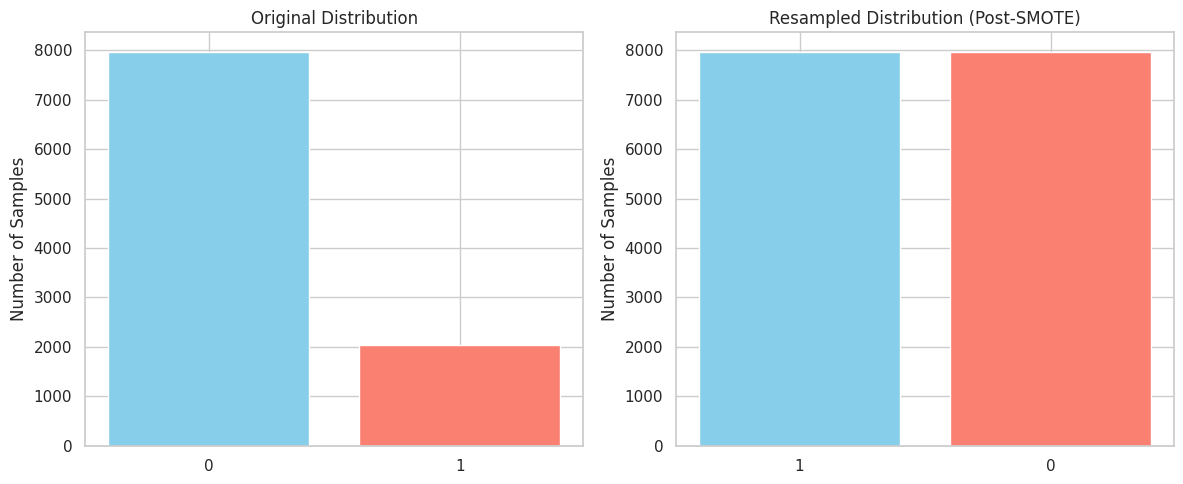

In [ ]:
import matplotlib.pyplot as plt

#  Prepare data for plotting
original_counts = y.value_counts()
resampled_counts = y_res.value_counts()

#  Create the side-by-side plot
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot Original
ax[0].bar(original_counts.index.astype(str), original_counts.values, color=['skyblue', 'salmon'])
ax[0].set_title('Original Distribution')
ax[0].set_ylabel('Number of Samples')

# Plot Resampled
ax[1].bar(resampled_counts.index.astype(str), resampled_counts.values, color=['skyblue', 'salmon'])
ax[1].set_title('Resampled Distribution (Post-SMOTE)')
ax[1].set_ylabel('Number of Samples')

plt.tight_layout()
plt.show()

In [ ]:
# If there is a string it can't convert, this will turn it into NaN
X_res = X_res.apply(pd.to_numeric, errors='coerce')

#  Fill any missing values created by the conversion (NaNs) with 0
X_res = X_res.fillna(0)

#  check the data types
print(X_res.dtypes)
X_res_reshaped = X_res.values.reshape((X_res.shape[0], X_res.shape[1], 1)).astype('float32')

rownumber              int64
creditscore            int64
gender                 int64
age                    int64
tenure                 int64
balance              float64
numofproducts          int64
hascrcard              int64
isactivemember         int64
estimatedsalary      float64
geography_Germany       bool
geography_Spain         bool
dtype: object


In [ ]:
# Cast the entire dataframe to float32
X_res_final = X_res.astype('float32')


X_res_reshaped = X_res_final.values.reshape((X_res_final.shape[0], X_res_final.shape[1], 1))

print("Final Shape:", X_res_reshaped.shape)
print("Data Type:", X_res_reshaped.dtype)


Final Shape: (15926, 12, 1)
Data Type: float32


CNN-LSTM Layer using Conv1D

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential # Import the sequential model class from keras
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Input

def create_model(num_conv_layers, input_length):
    model = Sequential()
    model.add(Input(shape=(input_length, 1)))
    current_length = input_length
    for _ in range(num_conv_layers):
        model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
        if current_length > 1:
            model.add(MaxPooling1D(pool_size=2))
            current_length = current_length // 2
    model.add(LSTM(64, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# The number of layer counts
layer_counts = [1, 2, 3, 5, 10]
results = {}

for n in layer_counts:
    print(f"Training model with {n} Conv1D layer(s)...")
    model = create_model(n, X_res_reshaped.shape[1])
    history = model.fit(X_res_reshaped, y_res, epochs=20, batch_size=32, verbose=1)
    results[n] = history.history['accuracy'][-1]
    print(f"Finished. Final Accuracy: {results[n]:.4f}")

Training model with 1 Conv1D layer(s)...
Epoch 1/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.5537 - loss: 0.6764
Epoch 2/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.6164 - loss: 0.6225
Epoch 3/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.6248 - loss: 0.6177
Epoch 4/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6202 - loss: 0.6162
Epoch 5/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6246 - loss: 0.6124
Epoch 6/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6237 - loss: 0.6087
Epoch 7/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6243 - loss: 0.6061
Epoch 8/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6272 - loss: 0.6037
Epoch 9/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6279 - loss: 0.5985
Epoch 10/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6174 - loss: 0.6152
Epoch 11/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6080 - loss: 0.6166
Epoch 

Training model with 1 Conv1D layer(s)...
Epoch 1/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.6197 - loss: 0.6596 - val_accuracy: 0.0000e+00 - val_loss: 0.9693
Epoch 2/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6242 - loss: 0.6536 - val_accuracy: 0.0000e+00 - val_loss: 0.9609
Epoch 3/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6242 - loss: 0.6516 - val_accuracy: 0.0000e+00 - val_loss: 0.9374
Epoch 4/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6259 - loss: 0.6447 - val_accuracy: 0.0000e+00 - val_loss: 0.8998
Epoch 5/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6392 - loss: 0.6330 - val_accuracy: 0.1434 - val_loss: 0.8340
Epoch 6/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6635 - loss: 0.6244 - val_accuracy: 0.5298 - val_loss: 0.8535
Epoch 7/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6703 - loss: 0.6195 - val_accuracy: 0.5395 - val_loss: 0.8659
Epoch 8/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6m

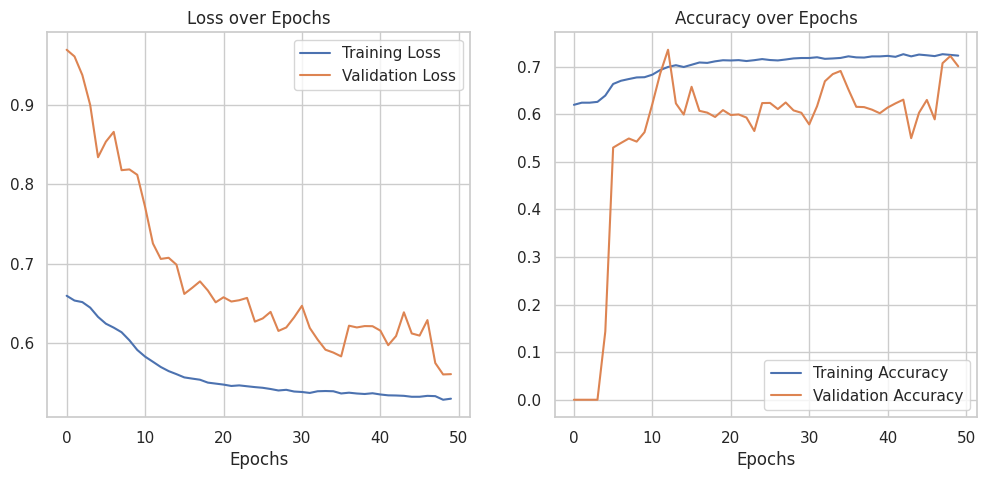

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Define the model
def create_model(num_conv_layers, input_length):
    model = Sequential()
    model.add(Input(shape=(input_length, 1)))

    for _ in range(num_conv_layers):
        model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
        model.add(BatchNormalization())
        model.add(MaxPooling1D(pool_size=2))

    model.add(LSTM(64, return_sequences=False))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


n = 1
print(f"Training model with {n} Conv1D layer(s)...")


model = create_model(n, X_res_reshaped.shape[1])


history = model.fit(
    X_res_reshaped,
    y_res,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


plt.figure(figsize=(12, 5))

# Plot loss over epochs
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.legend()

# Plot accuracy over epochs
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.legend()

plt.show()

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X_res_reshaped, y_res, test_size=0.2, random_state=42
)


def create_model(num_conv_layers, input_length):
    model = Sequential()
    model.add(Input(shape=(input_length, 1)))

    for i in range(num_conv_layers):
        model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
        model.add(BatchNormalization())

        if (i + 1) % 2 == 0:
            model.add(MaxPooling1D(pool_size=2))

    model.add(LSTM(64, return_sequences=False))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Number of layer counts
layer_counts = [1, 2, 3, 5]
results = {}

for n in layer_counts:
    print(f"\n--- Training with {n} Conv1D layer(s) ---")
    model = create_model(n, X_train.shape[1])

    # Train and validate
    history = model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        validation_data=(X_test, y_test),
        verbose=1
    )

    # Final validation accuracy
    results[n] = history.history['val_accuracy'][-1]
    print(f"Finished. Final Validation Accuracy for {n} layers: {results[n]:.4f}")

# Summary of experiments
print("\n--- Summary of Experiments ---")
for n, acc in results.items():
    print(f"{n} Layers: {acc:.4f} accuracy")


--- Training with 1 Conv1D layer(s) ---
Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.5447 - loss: 0.6883 - val_accuracy: 0.5643 - val_loss: 0.6816
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5636 - loss: 0.6839 - val_accuracy: 0.5643 - val_loss: 0.6810
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5661 - loss: 0.6833 - val_accuracy: 0.5659 - val_loss: 0.6815
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5673 - loss: 0.6838 - val_accuracy: 0.5659 - val_loss: 0.6812
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5675 - loss: 0.6834 - val_accuracy: 0.5647 - val_loss: 0.6811
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5694 - loss: 0.6833 - val_accuracy: 0.5669 - val_loss: 0.6809
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5688 - loss: 0.6828 - val_accuracy: 0.5656 - val_loss: 0.6808
Epoch 8/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accu

Starting training...
Epoch 1/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.5530 - loss: 0.6880 - val_accuracy: 0.5687 - val_loss: 0.6808
Epoch 2/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.5617 - loss: 0.6854 - val_accuracy: 0.5700 - val_loss: 0.6796
Epoch 3/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6266 - loss: 0.6593 - val_accuracy: 0.5684 - val_loss: 0.6903
Epoch 4/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.6463 - loss: 0.6477 - val_accuracy: 0.5722 - val_loss: 0.6955
Epoch 5/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.6461 - loss: 0.6450 - val_accuracy: 0.5935 - val_loss: 0.6695
Epoch 6/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6487 - loss: 0.6427 - val_accuracy: 0.6362 - val_loss: 0.6429
Epoch 7/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.6556 - loss: 0.6347 - val_accuracy: 0.5210 - val_loss: 0.6963
Epoch 8/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.6700 - l

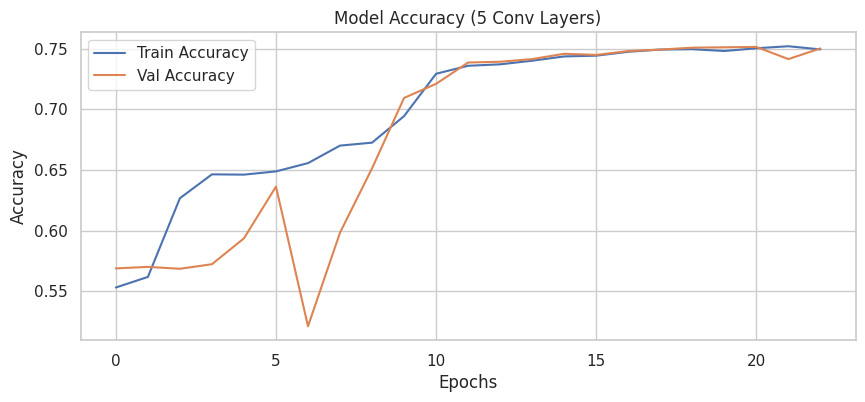

Model saved as 'final_churn_model_5conv.keras'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping # Import Early Stopping to prevent overfitting


def create_final_model(input_length):
    model = Sequential()
    model.add(Input(shape=(input_length, 1)))

    # Five layer CNN structure
    for _ in range(5):
        model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
        model.add(BatchNormalization())

    model.add(MaxPooling1D(pool_size=2))

    model.add(LSTM(64, return_sequences=False))
    model.add(Dropout(0.5))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

#  Train model
model = create_final_model(input_length=X_train.shape[1])

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Starting training...")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)


loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nFinal Accuracy on Unseen Data: {accuracy:.4f}")

# Plotting the results
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy (5 Conv Layers)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


model.save('final_churn_model_5conv.keras')
print("Model saved as 'final_churn_model_5conv.keras'")

Early stopping

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

def create_final_model(input_length):
    model = Sequential()
    model.add(Input(shape=(input_length, 1)))


    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())

    model.add(MaxPooling1D(pool_size=2))
    model.add(LSTM(128, return_sequences=False))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


model = create_final_model(input_length=X_train.shape[1])


early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Starting training...")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)


loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nFinal Accuracy on Unseen Data: {accuracy:.4f}")
model.save('final_churn_model.keras')

Starting training...
Epoch 1/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.5542 - loss: 0.6879 - val_accuracy: 0.5659 - val_loss: 0.6826
Epoch 2/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.5661 - loss: 0.6850 - val_accuracy: 0.5675 - val_loss: 0.6813
Epoch 3/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.5691 - loss: 0.6840 - val_accuracy: 0.5669 - val_loss: 0.6811
Epoch 4/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.5686 - loss: 0.6838 - val_accuracy: 0.5656 - val_loss: 0.6812
Epoch 5/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.5684 - loss: 0.6833 - val_accuracy: 0.5662 - val_loss: 0.6809
Epoch 6/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.5706 - loss: 0.6828 - val_accuracy: 0.5665 - val_loss: 0.6809
Epoch 7/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5710 - loss: 0.6826 - val_accuracy: 0.5669 - val_loss: 0.6805
Epoch 8/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5712 - 

Current shape check

In [ ]:

print(f"Original shape: {X_train.shape}")

X_train = np.expand_dims(X_train, axis=2)
X_test = np.expand_dims(X_test, axis=2)

print(f"New shape: {X_train.shape}")


Original shape: (12740, 12, 1)
New shape: (12740, 12, 1, 1)


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler


X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



print(f"New X_train shape: {X_train.shape}")

New X_train shape: (12740, 12)


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight
from sklearn.preprocessing import LabelEncoder


if y_train.dtype == 'object':
    le = LabelEncoder()
    y_train = le.fit_transform(y_train).astype(np.float32)
    y_test = le.transform(y_test).astype(np.float32)


X_train_2d = X_train.reshape(X_train.shape[0], -1).astype(np.float32)
X_test_2d = X_test.reshape(X_test.shape[0], -1).astype(np.float32)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_2d)
X_test_scaled = scaler.transform(X_test_2d)


X_train = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

#  Calculate Class Weights
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(weights))

#  Train model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.7722 - loss: 0.4770 - val_accuracy: 0.6905 - val_loss: 0.5849
Epoch 2/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8305 - loss: 0.3821 - val_accuracy: 0.7178 - val_loss: 0.5511
Epoch 3/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8446 - loss: 0.3546 - val_accuracy: 0.7219 - val_loss: 0.5428
Epoch 4/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8546 - loss: 0.3359 - val_accuracy: 0.7492 - val_loss: 0.5146
Epoch 5/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8631 - loss: 0.3202 - val_accuracy: 0.8013 - val_loss: 0.4270
Epoch 6/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8673 - loss: 0.3064 - val_accuracy: 0.8355 - val_loss: 0.3546
Epoch 7/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8790 - loss: 0.2892 - val_accuracy: 0.8399 - val_loss: 0.3562
Epoch 8/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8869 - loss: 0.2750 - val_accu

In [ ]:
from sklearn.utils import class_weight
import numpy as np

# Calculate weights to balance the importance of the classes
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(weights))

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8786 - loss: 0.2863 - val_accuracy: 0.8355 - val_loss: 0.3568
Epoch 2/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8843 - loss: 0.2751 - val_accuracy: 0.8387 - val_loss: 0.3595
Epoch 3/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8936 - loss: 0.2589 - val_accuracy: 0.8380 - val_loss: 0.3699


In [ ]:

model.save('best_churn_model.keras')

In [ ]:

model = create_final_model(input_length=X_train.shape[1])
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nFinal Accuracy on Unseen Data: {accuracy:.4f}")



from sklearn.metrics import f1_score

# Generate the predicted probabilities using the trained model
y_probs = model.predict(X_test)

# Loop through the thresholds to find the best F1-score
for threshold in [0.505, 0.51, 0.515, 0.52]:
    y_pred = (y_probs > threshold).astype("int32")
    f1 = f1_score(y_test, y_pred)
    print(f"Threshold {threshold} | F1-Score: {f1:.4f}")

Epoch 1/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.7633 - loss: 0.4957 - val_accuracy: 0.7913 - val_loss: 0.4513
Epoch 2/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8152 - loss: 0.4162 - val_accuracy: 0.8271 - val_loss: 0.3801
Epoch 3/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8277 - loss: 0.3842 - val_accuracy: 0.8327 - val_loss: 0.3687
Epoch 4/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8402 - loss: 0.3645 - val_accuracy: 0.8349 - val_loss: 0.3624
Epoch 5/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8493 - loss: 0.3488 - val_accuracy: 0.8402 - val_loss: 0.3581
Epoch 6/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8581 - loss: 0.3346 - val_accuracy: 0.8409 - val_loss: 0.3566
Epoch 7/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8624 - loss: 0.3200 - val_accuracy: 0.8406 - val_loss: 0.3531
Epoch 8/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.8716 - loss: 0.3035 - val_acc

In [ ]:
import tensorflow as tf
import numpy as np

X_train_final = np.asarray(X_train).astype('float32')
y_train_final = np.asarray(y_train).astype('float32')
X_test_final = np.asarray(X_test).astype('float32')
y_test_final = np.asarray(y_test).astype('float32')


if X_train_final.ndim == 2:
    X_train_final = np.expand_dims(X_train_final, axis=2)
    X_test_final = np.expand_dims(X_test_final, axis=2)

#  Reset the Graph
tf.keras.backend.clear_session()

#  Define the model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(13, 1)),
    tf.keras.layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

#  Train with class weights
weights = {0: 1.0, 1: 4.0}

history = model.fit(
    X_train_final, y_train_final,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_final, y_test_final),
    class_weight=weights,
    verbose=1
)

Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5706 - loss: 1.0827 - val_accuracy: 0.6500 - val_loss: 0.6596
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6666 - loss: 0.9496 - val_accuracy: 0.6874 - val_loss: 0.6080
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6934 - loss: 0.8966 - val_accuracy: 0.7141 - val_loss: 0.5658
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7108 - loss: 0.8573 - val_accuracy: 0.7439 - val_loss: 0.5272
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7274 - loss: 0.8211 - val_accuracy: 0.7348 - val_loss: 0.5494
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7502 - loss: 0.7750 - val_accuracy: 0.7367 - val_loss: 0.5583
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7703 - loss: 0.7360 - val_accuracy: 0.7586 - val_loss: 0.5130
Epoch 8/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7809 - loss: 0.7148 - val_accuracy: 0

In [ ]:
import numpy as np
unique, counts = np.unique(y_res, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(0): np.int64(7963), np.int64(1): np.int64(7963)}


Mean and standard deviation

In [ ]:

print(f"Mean of X: {np.mean(X_res_reshaped):.4f}")
print(f"Std Dev of X: {np.std(X_res_reshaped):.4f}")

Mean of X: 15672.6758
Std Dev of X: 41829.5742


In [ ]:
from sklearn.preprocessing import StandardScaler


n_samples, time_steps, features = X_res_reshaped.shape
X_flat = X_res_reshaped.reshape(n_samples, time_steps * features)

#  Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)

#  Reshape back to 3D for the CNN-LSTM
X_res_reshaped = X_scaled.reshape(n_samples, time_steps, features)

# Check the new stats
print(f"New Mean: {np.mean(X_res_reshaped):.4f}")
print(f"New Std Dev: {np.std(X_res_reshaped):.4f}")

New Mean: 0.0000
New Std Dev: 1.0000


In [ ]:
print(f"Data shape: {X_res.shape}")

Data shape: (15926, 12)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Input


model = Sequential([
    Input(shape=(X_res.shape[1], 1)),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])


model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


X_res_reshaped = np.asarray(X_res_reshaped).astype(np.float32)
y_res = np.asarray(y_res).astype(np.float32)


model.fit(X_res_reshaped, y_res, epochs=20, batch_size=32)

Epoch 1/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7305 - loss: 0.5322
Epoch 2/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8080 - loss: 0.4241
Epoch 3/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8248 - loss: 0.3920
Epoch 4/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8307 - loss: 0.3787
Epoch 5/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8360 - loss: 0.3701
Epoch 6/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8387 - loss: 0.3638
Epoch 7/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8420 - loss: 0.3601
Epoch 8/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8438 - loss: 0.3549
Epoch 9/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8451 - loss: 0.3530
Epoch 10/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8479 - loss: 0.3488
Epoch 11/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8488 - loss: 0.3458
Epoch 12/20
498/498 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

Epoch 1/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6452 - loss: 0.6307 - val_accuracy: 0.1918 - val_loss: 0.8354
Epoch 2/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7053 - loss: 0.5754 - val_accuracy: 0.7053 - val_loss: 0.6228
Epoch 3/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7391 - loss: 0.5359 - val_accuracy: 0.7850 - val_loss: 0.5326
Epoch 4/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7602 - loss: 0.5086 - val_accuracy: 0.7982 - val_loss: 0.4981
Epoch 5/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7709 - loss: 0.4907 - val_accuracy: 0.8032 - val_loss: 0.4772
Epoch 6/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7838 - loss: 0.4760 - val_accuracy: 0.8070 - val_loss: 0.4558
Epoch 7/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7900 - loss: 0.4632 - val_accuracy: 0.8142 - val_loss: 0.4307
Epoch 8/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7933 - loss: 0.4533 - val_accuracy: 0

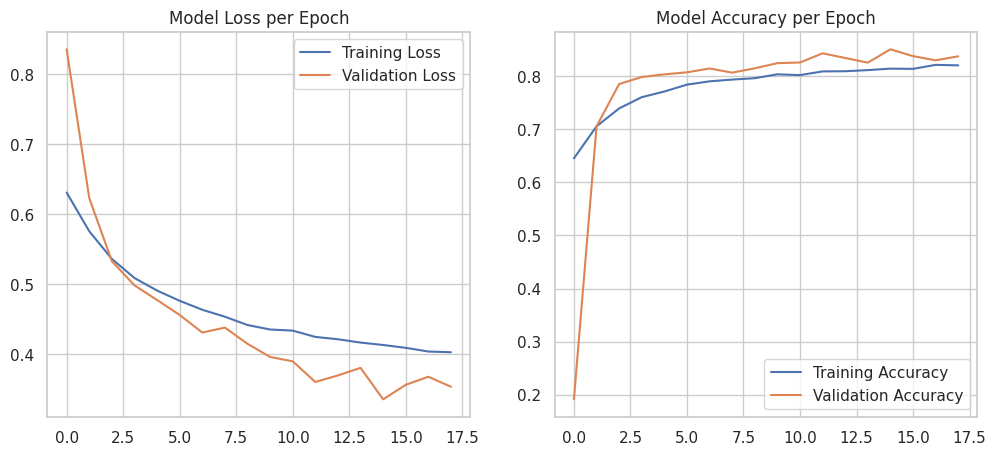

Model saved successfully!


In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Define Model
model = Sequential([
    Input(shape=(X_res_reshaped.shape[1], 1)),
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(), # Added for stability
    MaxPooling1D(pool_size=2),
    LSTM(64, return_sequences=False),
    Dropout(0.5), # Increased to prevent overfitting
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


history = model.fit(
    X_res_reshaped, y_res,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss per Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy per Epoch')
plt.legend()

plt.show()

model.save('final_churn_model.keras')
print("Model saved successfully!")

Prediction

In [ ]:
from sklearn.model_selection import train_test_split


#  Create the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_test_values = X_test.values
X_test_reshaped = X_test_values.reshape(X_test_values.shape[0], X_test_values.shape[1], 1)
X_test_reshaped = X_test_reshaped.astype('float32')

#  Predict
y_pred = (model.predict(X_test_reshaped) > 0.5).astype("int32")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


X train

In [ ]:
import numpy as np

X_train = np.array(X_train, dtype=np.float32)
X_test = np.array(X_test, dtype=np.float32)


y_train = np.array(y_train, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)


print(f"X_train dtype: {X_train.dtype}")
print(f"y_train dtype: {y_train.dtype}")

X_train dtype: float32
y_train dtype: float32


In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (8000, 12)
y_train shape: (8000,)


In [ ]:
print("X_train shape:", X_train_final.shape)
print("y_train shape:", y_train.shape)

X_train shape: (12740, 12, 1)
y_train shape: (8000,)


In [ ]:
from tensorflow.keras import layers, models, optimizers

X_train_final = X_train_final[:8000]
X_test_final = X_test_final[:2000]

# Print verification to ensure everything matches
print("Verified X_train shape:", X_train_final.shape)
print("Verified y_train shape:", y_train.shape)
print("Verified X_test shape:", X_test_final.shape)
print("Verified y_test shape:", y_test.shape)

# 2. Define the simplified model (shape: 12)
model = models.Sequential([
    layers.Input(shape=(12, 1)),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

#  Use gradient clipping to stop weights from exploding
opt = optimizers.Adam(learning_rate=0.0001, clipvalue=1.0)

model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train_final, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_final, y_test),
    class_weight=class_weight_dict,
    verbose=1
)

Verified X_train shape: (8000, 12, 1)
Verified y_train shape: (8000,)
Verified X_test shape: (2000, 12, 1)
Verified y_test shape: (2000,)
Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5132 - loss: 0.7636 - val_accuracy: 0.6225 - val_loss: 0.6545
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5906 - loss: 0.6854 - val_accuracy: 0.7285 - val_loss: 0.5913
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6529 - loss: 0.6437 - val_accuracy: 0.7810 - val_loss: 0.5560
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6931 - loss: 0.6123 - val_accuracy: 0.7970 - val_loss: 0.5347
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7178 - loss: 0.5893 - val_accuracy: 0.8025 - val_loss: 0.5225
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7324 - loss: 0.5893 - val_accuracy: 0.8035 - val_loss: 0.5148
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7487 - loss: 0.5716 - val_ac

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report


# Convert Pandas DataFrames to NumPy arrays using values
X_array = X.values if hasattr(X, 'values') else X
y_array = y.values if hasattr(y, 'values') else y

# Reshape and Split
X_train, X_test, y_train, y_test = train_test_split(
    X_array.reshape(X_array.shape[0], -1),
    y_array,
    test_size=0.2,
    random_state=42
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).reshape(-1, 12, 1)
X_test = scaler.transform(X_test).reshape(-1, 12, 1)


model = models.Sequential([
    layers.Input(shape=(12, 1)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])


opt = optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])


class_weight_dict = {0: 1.0, 1: 5.0}

early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=20, restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)


y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

print(classification_report(y_test, y_pred))

Epoch 1/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5871 - loss: 1.1320 - val_accuracy: 0.6385 - val_loss: 0.6570
Epoch 2/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6472 - loss: 1.0281 - val_accuracy: 0.6630 - val_loss: 0.6244
Epoch 3/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6719 - loss: 0.9896 - val_accuracy: 0.7010 - val_loss: 0.5925
Epoch 4/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6976 - loss: 0.9429 - val_accuracy: 0.6960 - val_loss: 0.5830
Epoch 5/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7120 - loss: 0.9143 - val_accuracy: 0.7200 - val_loss: 0.5565
Epoch 6/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7219 - loss: 0.9093 - val_accuracy: 0.7260 - val_loss: 0.5477
Epoch 7/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7285 - loss: 0.8980 - val_accuracy: 0.7260 - val_loss: 0.5444
Epoch 8/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7297 - loss: 0.8912 - val_accu

In [ ]:
# Train with the stabilized scaled data
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    verbose=1
)

# Evaluate the model
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

print(classification_report(y_test, y_pred, zero_division=0))

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7606 - loss: 0.8061 - val_accuracy: 0.7435 - val_loss: 0.5069
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7655 - loss: 0.8037 - val_accuracy: 0.7455 - val_loss: 0.5113
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7680 - loss: 0.7879 - val_accuracy: 0.7380 - val_loss: 0.5146
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7626 - loss: 0.8015 - val_accuracy: 0.7510 - val_loss: 0.4993
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7648 - loss: 0.7886 - val_accuracy: 0.7450 - val_loss: 0.5035
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7636 - loss: 0.7950 - val_accuracy: 0.7395 - val_loss: 0.5049
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7671 - loss: 0.7850 - val_accuracy: 0.7320 - val_loss: 0.5104
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7679 - loss: 0.7942 - val_accuracy: 0.

Recall

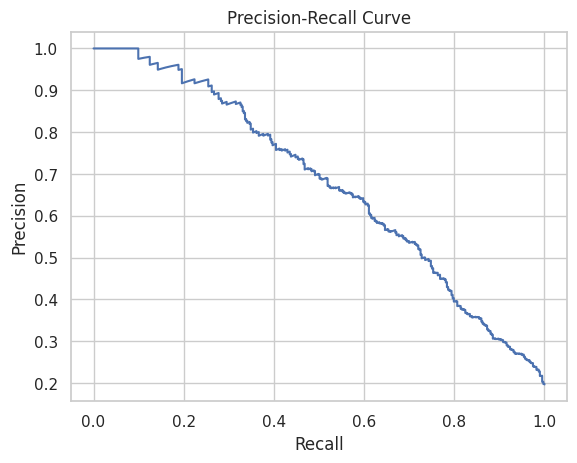

In [ ]:
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_probs)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

In [ ]:
from sklearn.metrics import f1_score, recall_score, roc_auc_score, brier_score_loss


print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")


y_prob = model.predict(X_test_reshaped).flatten()
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Brier Score: {brier_score_loss(y_test, y_prob):.4f}")

F1 Score: 0.5369
Recall: 0.7964
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
ROC-AUC: 0.5588
Brier Score: 0.5476


In [ ]:

y_prob = model.predict(X_test_reshaped)


import numpy as np
for t in [0.4, 0.5, 0.6, 0.7, 0.8]:
    y_pred_t = (y_prob > t).astype("int32")
    cm = confusion_matrix(y_test, y_pred_t)
    print(f"Threshold {t}:")
    print(cm)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Threshold 0.4:
[[615 992]
 [104 289]]
Threshold 0.5:
[[615 992]
 [104 289]]
Threshold 0.6:
[[616 991]
 [104 289]]
Threshold 0.7:
[[616 991]
 [104 289]]
Threshold 0.8:
[[616 991]
 [104 289]]


ROC-AUC Curve

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


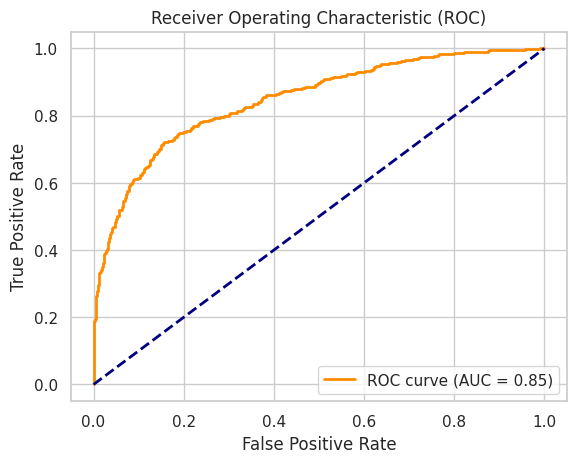

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Get raw probabilities
y_probs = model.predict(X_test)

# 2. Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# 3. Plot
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # The "Random" line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Check the distribution of the predictions
print(f"Mean probability: {y_probs.mean():.4f}")
print(f"Max probability: {y_probs.max():.4f}")
print(f"Min probability: {y_probs.min():.4f}")

Mean probability: 0.4121
Max probability: 1.0000
Min probability: 0.0025


Confusion matrix

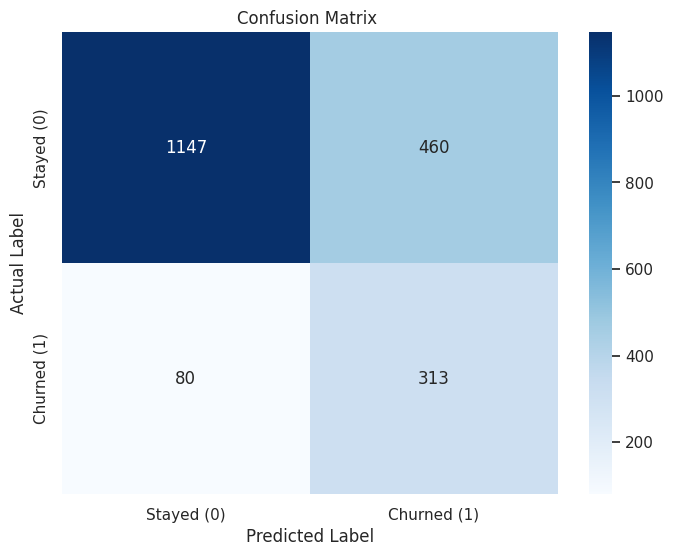

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed (0)', 'Churned (1)'],
            yticklabels=['Stayed (0)', 'Churned (1)'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix ')
plt.show()

Feature importance

In [ ]:
# Drop the columns that identify rows/customers
X_cleaned = X.drop(columns=['customerid', 'rownumber'], errors='ignore')


X_array = X_cleaned.values
X_train, X_test, y_train, y_test = train_test_split(
    X_array, y_array, test_size=0.2, random_state=42
)

# Scale cleaned data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).reshape(-1, X_cleaned.shape[1], 1)
X_test_scaled = scaler.transform(X_test).reshape(-1, X_cleaned.shape[1], 1)


model = models.Sequential([
    layers.Input(shape=(X_cleaned.shape[1], 1)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    class_weight={0: 1.0, 1: 5.0},
    callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=0
)

print("Model retrained on clean features.")

Model retrained on clean features.


Permutation importance

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report

#  Data preperation
df_clean = df.drop(columns=['customerid', 'rownumber', 'surname'], errors='ignore')
df_clean = pd.get_dummies(df_clean, drop_first=True)

target_col = 'exited'
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)


y_pred = rf_model.predict(X_test)
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))


result = permutation_importance(
    rf_model, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)


print("\nPermutation Importance (Unseen Data):")
sorted_idx = result.importances_mean.argsort()
for i in sorted_idx:
    print(f"{X.columns[i]}: {result.importances_mean[i]:.4f}")

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.79      0.46      0.58       393

    accuracy                           0.87      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000


Permutation Importance (Unseen Data):
estimatedsalary: -0.0002
geography_Spain: 0.0025
creditscore: 0.0026
hascrcard: 0.0040
gender_Male: 0.0057
tenure: 0.0070
balance: 0.0185
geography_Germany: 0.0189
isactivemember: 0.0241
numofproducts: 0.0617
age: 0.0674


In [ ]:

result = permutation_importance(rf_model, X_test, y_test, n_repeats=10)

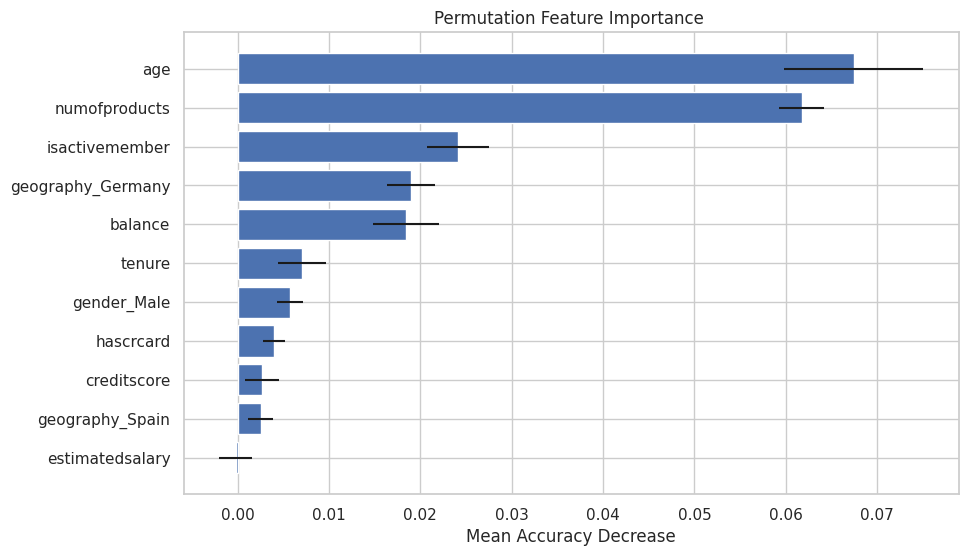

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


result = permutation_importance(rf_model, X_test, y_test, n_repeats=10, random_state=42)


feature_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
})


feature_importance = feature_importance.sort_values(by='importance_mean', ascending=False)

#  Plot results
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance_mean'], xerr=feature_importance['importance_std'])
plt.xlabel("Mean Accuracy Decrease")
plt.title("Permutation Feature Importance ")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
print(f"Total number of layers: {len(model.layers)}")

Total number of layers: 6
